In [74]:
import os
print("Working dir is now:", os.getcwd())

# DATA_PATH = "/Users/adrian/Documents/01_projects/14_4D_lab/data"
# OUTPUT_PATH = "/Users/adrian/Documents/01_projects/14_4D_lab/output/05_plotting_energy_grids"

# PREPROCESSED_PATH = DATA_PATH + "/preprocessed/01_first_analysises"


# # create output path if it does not exist
# if not os.path.exists(OUTPUT_PATH):
#     os.makedirs(OUTPUT_PATH)

# if not os.path.exists(PREPROCESSED_PATH):
#     os.makedirs(PREPROCESSED_PATH)

%load_ext autoreload
%autoreload 2

Working dir is now: /Users/adrian/Documents/01_projects/14_4D_lab
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [75]:

# able to run example script from within Jupyter notebook in package
# import sys
# loc = os.path.abspath(os.path.join(notebook_dir, '..', '..', 'src'))
# sys.path.append(loc)

# other basic imports
import time
import numpy as np
import pandas as pd
import torch
from gnm import *
from gnm import defaults, utils, evaluation, fitting, generative_rules, weight_criteria


In [76]:
import matplotlib.pyplot as plt
# import seaborn as sns

In [77]:
import os

# Limit BLAS libraries (NumPy, SciPy, Pandas)
os.environ["OMP_NUM_THREADS"] = "2"
os.environ["OPENBLAS_NUM_THREADS"] = "2"
os.environ["MKL_NUM_THREADS"] = "2"
os.environ["VECLIB_MAXIMUM_THREADS"] = "2"
os.environ["NUMEXPR_NUM_THREADS"] = "2"

# Limit PyTorch
os.environ["TORCH_NUM_THREADS"] = "2"

# Limit TensorFlow
os.environ["TF_NUM_INTRAOP_THREADS"] = "2"
os.environ["TF_NUM_INTEROP_THREADS"] = "2"

# Set device to CPU instead of MPS (Metal Performance Shaders)
import torch
device = torch.device("cpu")  # instead of "mps"


In [78]:
# device is the GPU if available, otherwise the CPU - GPU is much faster but ensure you have 
# GPU available in your PC/HPC

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
DEVICE

device(type='cpu')

In [79]:
connectomes_binarized = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/data/preprocessed/01_first_analysises/connectomes_binarized.npy")
consensus_connectome_bin = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/data/preprocessed/01_first_analysises/consensus_connectome_bin.npy")

dist_mat = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/data/preprocessed/01_first_analysises/distance_matrix.npy")
df_identifiers = pd.read_csv("/Users/adrian/Documents/01_projects/14_4D_lab/data/preprocessed/01_first_analysises/df_identifiers.csv") 
all_connectomes = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/data/preprocessed/01_first_analysises/all_connectomes.npy")
# df_graph_measures_bin = pd.read_csv("/Users/adrian/Documents/01_projects/14_4D_lab/data/preprocessed/01_first_analysises/df_graph_measures_bin.csv")
df_graph_measures_all = pd.read_csv("/Users/adrian/Documents/01_projects/14_4D_lab/data/preprocessed/01_first_analysises/df_graph_measures_all.csv")
df_graph_measures = df_graph_measures_all

In [80]:
# distance_matrix = defaults.get_distance_matrix(device=DEVICE)
distance_matrix = torch.Tensor(dist_mat)
binary_consensus_network = torch.Tensor(consensus_connectome_bin) #  defaults.get_binary_network(device=DEVICE)

distance_matrix = torch.load("/Users/adrian/Documents/01_projects/14_4D_lab/src/imported_libraries/GenerativeNetworkModels/src/gnm/defaults/distance_matrices/AAL_DISTANCES.pt")
binary_consensus_network = torch.load("/Users/adrian/Documents/01_projects/14_4D_lab/src/imported_libraries/GenerativeNetworkModels/src/gnm/defaults/binary_networks/CALM_BINARY_CONSENSUS.pt")
# distance_matrix = defaults.get_distance_matrix(device=DEVICE)
# binary_consensus_network = defaults.get_binary_network(device=DEVICE)

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_19720/232710054.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  distance_matrix = torch.load("/Users/adrian/Do

In [81]:
num_connections = int( binary_consensus_network.sum().item() / 2 )
print(f"The binary consensus network contains {num_connections} connections.")

The binary consensus network contains 400 connections.


In [82]:
eta_values = torch.linspace(-5, -1, 3)
gamma_values = torch.linspace(-0.5, 0.5, 3)

binary_sweep_parameters = fitting.BinarySweepParameters(
    eta = eta_values,
    gamma = gamma_values,
    lambdah = torch.Tensor([0.0]),
    distance_relationship_type = ["powerlaw"],
    preferential_relationship_type = ["powerlaw"],
    heterochronicity_relationship_type = ["powerlaw"],
    generative_rule = [generative_rules.MatchingIndex()],
    num_iterations = [num_connections],
)

weighted_sweep_parameters = fitting.WeightedSweepParameters(
    alpha = [0.01],
    optimisation_criterion = [weight_criteria.DistanceWeightedCommunicability(distance_matrix=distance_matrix) ],
)   

num_simulations = 100

sweep_config = fitting.SweepConfig(
    binary_sweep_parameters = binary_sweep_parameters,
    weighted_sweep_parameters = weighted_sweep_parameters,
    num_simulations = num_simulations,
    distance_matrix = [distance_matrix]    
)

In [83]:
criteria = [ evaluation.ClusteringKS(), evaluation.DegreeKS(), evaluation.EdgeLengthKS(distance_matrix) ]
energy = evaluation.MaxCriteria( criteria )
binary_evaluations = [energy]


In [84]:
weighted_evaluations = [ evaluation.WeightedNodeStrengthKS(normalise=True), evaluation.WeightedClusteringKS() ]

In [85]:

start_time = time.perf_counter()

experiments = fitting.perform_sweep(sweep_config=sweep_config, 
                                binary_evaluations=binary_evaluations, 
                                real_binary_matrices=binary_consensus_network,
                                weighted_evaluations=weighted_evaluations,
                                save_model = False,
                                save_run_history = False,
)

end_time = time.perf_counter()
# 7 minutes for 100 simulations with 9 parameter combinations

Using device: None for GNM simulations


KeyboardInterrupt: 

In [ ]:
total_seconds = 6 * 60 + 58.7
number_parameters = 100*100
number_simulations = 100 
total_seconds = total_seconds / 9 * number_parameters
time_in_hours = int(total_seconds / 3600)
time_in_min = int(total_seconds % 3600 // 60)
remaining_seconds = int(total_seconds % 60)
print(f"Total time for {number_simulations} simulations with {number_parameters} parameter combinations: {time_in_hours} hours, {time_in_min} minutes and {remaining_seconds} seconds.")

Total time for 100 simulations with 10000 parameter combinations: 129 hours, 13 minutes and 42 seconds.


In [ ]:
print(f"Sweep took {end_time - start_time:0.3f} seconds.")

total_simulations = num_simulations * len(eta_values) * len(gamma_values)

print(f"Total number of simulations: {total_simulations}")

print(f"Average time per simulation: {(end_time - start_time) / total_simulations:0.3f} seconds.")

Sweep took 418.671 seconds.
Total number of simulations: 900
Average time per simulation: 0.465 seconds.


In [ ]:
optimal_experiments, optimal_energies = fitting.optimise_evaluation(
    experiments=experiments,
    criterion=energy,
)

optimal_experiment = optimal_experiments[0]
optimal_energy = optimal_energies[0]

In [ ]:
print(f"Optimal energy: {optimal_energy:0.3f}")
print(f"Optimal value of eta: {optimal_experiment.run_config.binary_parameters.eta:0.2f}")
print(f"Optimal value of gamma: {optimal_experiment.run_config.binary_parameters.gamma:0.2f}")

Optimal energy: 0.330
Optimal value of eta: -5.00
Optimal value of gamma: 0.00


In [ ]:
experiments[0]

Experiment(run_config=RunConfig(binary_parameters=BinaryGenerativeParameters(eta=tensor(-5.), gamma=tensor(-0.5000), lambdah=tensor(0.), distance_relationship_type='powerlaw', preferential_relationship_type='powerlaw', heterochronicity_relationship_type='powerlaw', generative_rule=<gnm.generative_rules.generative_rules.MatchingIndex object at 0x30492de10>, num_iterations=400, prob_offset=1e-06, binary_updates_per_iteration=1), num_simulations=100, seed_adjacency_matrix=None, distance_matrix=tensor([[0.0000, 0.5303, 0.3052,  ..., 0.7891, 0.5180, 0.7986],
        [0.5303, 0.0000, 0.4924,  ..., 0.5788, 0.7938, 0.5220],
        [0.3052, 0.4924, 0.0000,  ..., 0.6583, 0.6355, 0.7755],
        ...,
        [0.7891, 0.5788, 0.6583,  ..., 0.0000, 0.6861, 0.3155],
        [0.5180, 0.7938, 0.6355,  ..., 0.6861, 0.0000, 0.6856],
        [0.7986, 0.5220, 0.7755,  ..., 0.3155, 0.6856, 0.0000]]), weighted_parameters=WeightedGenerativeParameters(alpha=0.01, optimisation_criterion=<gnm.weight_criteria.

In [ ]:
# for i in range(9): 
#     print(experiments[i].run_config.binary_parameters.eta, experiments[i].run_config.binary_parameters.gamma)
#     print(experiments[i].evaluation_results.binary_evaluations['MaxCriteria(ClusteringKS, DegreeKS, EdgeLengthKS)'].shape)
#     print(experiments[i].evaluation_results.binary_evaluations['MaxCriteria(ClusteringKS, DegreeKS, EdgeLengthKS)'].mean())

eta_arr = []
gamma_arr = []
experiments_means = []

for i in range(9): 
    eta_arr.append(experiments[i].run_config.binary_parameters.eta)
    gamma_arr.append(experiments[i].run_config.binary_parameters.gamma)
    # print(experiments[i].evaluation_results.binary_evaluations['MaxCriteria(ClusteringKS, DegreeKS, EdgeLengthKS)'].shape)
    experiments_means.append(experiments[i].evaluation_results.binary_evaluations['MaxCriteria(ClusteringKS, DegreeKS, EdgeLengthKS)'].mean())

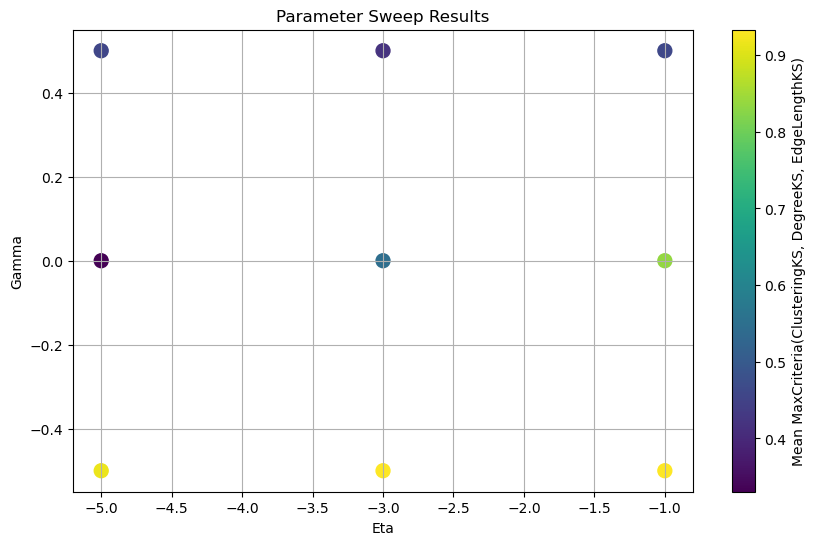

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(eta_arr, gamma_arr, c=experiments_means, cmap='viridis', s=100)
plt.colorbar(label='Mean MaxCriteria(ClusteringKS, DegreeKS, EdgeLengthKS)')
plt.xlabel('Eta')
plt.ylabel('Gamma')
plt.title('Parameter Sweep Results')
plt.grid(True)
plt.show()

In [ ]:
experiments[0].evaluation_results.binary_evaluations['MaxCriteria(ClusteringKS, DegreeKS, EdgeLengthKS)']

tensor([[0.9111],
        [0.9222],
        [0.9333],
        [0.9333],
        [0.9333],
        [0.9222],
        [0.9111],
        [0.9222],
        [0.9111],
        [0.9222],
        [0.9111],
        [0.9111],
        [0.9333],
        [0.9222],
        [0.9333],
        [0.9222],
        [0.9111],
        [0.9222],
        [0.9333],
        [0.9111],
        [0.9222],
        [0.9111],
        [0.9222],
        [0.9111],
        [0.9222],
        [0.9222],
        [0.9222],
        [0.9222],
        [0.9222],
        [0.9111],
        [0.9000],
        [0.9111],
        [0.8889],
        [0.9111],
        [0.9222],
        [0.9333],
        [0.9111],
        [0.9333],
        [0.9111],
        [0.9000],
        [0.9111],
        [0.9333],
        [0.9111],
        [0.9222],
        [0.9000],
        [0.9000],
        [0.9111],
        [0.9333],
        [0.9000],
        [0.9333],
        [0.9111],
        [0.9000],
        [0.9222],
        [0.9333],
        [0.9000],
        [0

## Weighted example script 

In [87]:
# basic imports from within the package plus torch and time
from gnm import defaults, utils, fitting, generative_rules, weight_criteria, evaluation
import torch
import time
import numpy as np

# Remember, the device is the hardware on which the code will run. Use a GPU for speed if 
# you have one, as this utlizes parallelization (running lots of models at the same time).
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# load the example data
# distance_matrix = defaults.get_distance_matrix(device=DEVICE)
# weighted_consensus_network = defaults.get_weighted_network(device=DEVICE)
# binary_consensus_network = defaults.get_binary_network(device=DEVICE)

distance_matrix = torch.load("/Users/adrian/Documents/01_projects/14_4D_lab/src/imported_libraries/GenerativeNetworkModels/src/gnm/defaults/distance_matrices/AAL_DISTANCES.pt")
binary_consensus_network = torch.load("/Users/adrian/Documents/01_projects/14_4D_lab/src/imported_libraries/GenerativeNetworkModels/src/gnm/defaults/binary_networks/CALM_BINARY_CONSENSUS.pt")
weighted_consensus_network = torch.load("/Users/adrian/Documents/01_projects/14_4D_lab/src/imported_libraries/GenerativeNetworkModels/src/gnm/defaults/weighted_networks/CALM_WEIGHTED_CONSENSUS.pt")

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_19720/1562377848.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  distance_matrix = torch.load("/Users/adrian/

In [88]:
# set fixed eta and gamma - usually you'd want to sweep through these too but here we will keep them
# constant for ease of testing
eta = torch.Tensor([-0.1])
gamma = torch.Tensor([0.1])

# set space for weighted sweep - test for 2x2x2 grid search,
# uncomment np.linspace for a more extensive search
alpha_values = [1, 2, 3] # np.linspace(-1, 1, 0.1)
omega_values = [1, 2, 3] # np.linspace(-1, 1, 0.1)

# define the number of simulations we want to run
num_simulations = 100

# set the number of connections - remember to count per connection without weight initially
num_connections = int( torch.where(weighted_consensus_network > 1, 1, 0).sum().item() / 2 )
print(f"The weighted consensus network contains {num_connections} connections.")

The weighted consensus network contains 400 connections.


In [89]:
# Even though we're running a weighted model, this operates on top of a binary network so we
# must define the binary sweep parameters too. 
binary_sweep_parameters = fitting.BinarySweepParameters(
    eta = eta,
    gamma = gamma,
    lambdah = torch.Tensor([0.0]),
    distance_relationship_type = ["powerlaw"],
    preferential_relationship_type = ["powerlaw"],
    heterochronicity_relationship_type = ["powerlaw"],
    generative_rule = [generative_rules.MatchingIndex()],
    num_iterations = [num_connections],
)

# we create a set of optimization criteria using our many alpha values - the question
# we're asking here is 'What is the optimium level of communicability that best matches the 
# given real life connectome?'
weighted_sweep_parameters = fitting.WeightedSweepParameters(
    alpha = alpha_values,
    optimisation_criterion = [ 
        weight_criteria.DistanceWeightedCommunicability(distance_matrix=distance_matrix, omega=omega_value)
        for omega_value in omega_values],
)

# Now we define the sweep configuation - this allows for running through every single combination 
# of parameters and saving the results.
sweep_config = fitting.SweepConfig(
    binary_sweep_parameters = binary_sweep_parameters,
    weighted_sweep_parameters = weighted_sweep_parameters,
    num_simulations = num_simulations,
    distance_matrix = [distance_matrix],
)

In [90]:
# Create our evaluation critereon - this tells you how close the generative model 
# is to your actual connectome in terms of a given set of topological or topographical 
# criteria - in this case, we use the KS Statistic to compare clustering, degree, and edge length

# binary evaluations
criteria = [ evaluation.ClusteringKS(), evaluation.DegreeKS(), evaluation.EdgeLengthKS(distance_matrix) ]
energy_equation = evaluation.MaxCriteria( criteria )
binary_evaluations = [energy_equation]

# weighted evaluations
weighted_evaluations = [ evaluation.WeightedNodeStrengthKS(normalise=True), evaluation.WeightedClusteringKS() ]


In [91]:
# so we can see how long the sweep takes, we can start a timer
# and stop it when the sweep is finished
start_time = time.perf_counter()

# Given all our parameter configurations, we can now run the sweep.
# This will take a minute, so be patient.
experiments = fitting.perform_sweep(
    sweep_config=sweep_config, 
    binary_evaluations=binary_evaluations, 
    real_binary_matrices=binary_consensus_network,
    real_weighted_matrices=weighted_consensus_network,
    weighted_evaluations=weighted_evaluations,
    save_model = False,
    save_run_history = False, 
    verbose=True # set this to True if you want to see a progress bar below
)

# end the timer
end_time = time.perf_counter()

Using device: None for GNM simulations


Configuration Iterations: 100%|██████████| 9/9 [09:30<00:00, 63.41s/it]

Average time per run: 60.23 seconds
Total time for sweep: 542.11 seconds


In [92]:
# now we can see how long the sweep took

print(f"Sweep took {end_time - start_time:0.3f} seconds.")

total_simulations = num_simulations * len(alpha_values) * len(omega_values)

print(f"Total number of simulations: {total_simulations}")

print(f"Average time per simulation: {(end_time - start_time) / total_simulations:0.3f} seconds.")

Sweep took 543.097 seconds.
Total number of simulations: 900
Average time per simulation: 0.603 seconds.
